In [31]:
# Instala os pacotes necessários
!pip install feature-engine
!pip install catboost
!pip install shap

In [32]:
# Importa as bibliotecas
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from feature_engine.selection import SmartCorrelatedSelection
from feature_engine.transformation import LogCpTransformer
from lightgbm import LGBMClassifier
from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
import shap

# Configura o pandas para exibir todas as colunas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)

# Configura o scikit-learn para que os transformadores retornem DataFrames do pandas
set_config(transform_output='pandas')

In [33]:
# Define constantes para caminhos de arquivo e semente aleatória
ROOT = "/content/drive/MyDrive/ml-project" # Diretório raiz do projeto (atualize se necessário)
FILE = "/data/smart-contract-dataset.csv" # Nome do arquivo do dataset
SEED = 78 # Semente aleatória para reprodutibilidade

In [34]:
# Carrega o dataset
# Assume que o arquivo CSV está no mesmo diretório que o notebook,
# ou o caminho ROOT precisa ser usado se o arquivo estiver em outro local.
# data = pd.read_csv(os.path.join(ROOT, FILE)) # Descomente se o arquivo estiver no ROOT
data = pd.read_csv(f"{ROOT}/{FILE}") # Assume que o arquivo está no diretório atual

In [35]:
# Renomeia as colunas para serem mais amigáveis ao Python
# Substitui caracteres especiais por underscores ou representações textuais
data = data.rename(
    columns=lambda col: (
        col
        .replace('<', 'lt') # menor que
        .replace('>', 'gt') # maior que
        .replace('__', '_double_underscore') # underscore duplo
        .replace(':', 'colon') # dois pontos
    )
)

In [36]:
more_features = pd.read_csv(f"{ROOT}/data/solidity_word_counts.csv")
# Variáveis extraídas dos códigos fontes que contém os contratos inteligentes.
# Representam contagem de termos que são citados no artigo, mas não estão nos dados originais.

In [37]:
# Junta os dois datasets
data = pd.merge(
    data,
    more_features,
    on='hash_id'
)

In [38]:
# Separa as features (X) e o alvo (y)
# Seleciona todas as colunas numéricas a partir da 4ª coluna como features
X = data.iloc[:, 3:].select_dtypes(include="number")
# Seleciona a coluna 'label' como a variável alvo
y = data.label

In [39]:
# Divide os dados em conjuntos de treinamento/validação e teste
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED # 20% para o conjunto de teste
)

# Divide o conjunto de treinamento/validação em conjuntos de treinamento e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=SEED # 20% do train_val para o conjunto de validação
)

## Definição de Transformadores Customizados


In [40]:
# Agregar variáveis "OPCODE" semelhantes.
# Diminui dimensionalide e esparsidade dos dados.
OPCODE_CATEGORIES = {
    'Arithmetic': ['ADD', 'MUL', 'SUB', 'DIV', 'SDIV', 'MOD', 'SMOD', 'ADDMOD', 'MULMOD', 'EXP', 'SIGNEXTEND'],
    'ComparisonLogic': ['LT', 'GT', 'SLT', 'SGT', 'EQ', 'ISZERO', 'AND', 'OR', 'XOR', 'NOT', 'BYTE', 'SHL', 'SHR', 'SAR'],
    'Hashing': ['SHA3'],
    'Environmental': [
        'ADDRESS', 'BALANCE', 'ORIGIN', 'CALLER', 'CALLVALUE',
        'CALLDATALOAD', 'CALLDATASIZE', 'CALLDATACOPY',
        'CODESIZE', 'CODECOPY',
        'GASPRICE', 'EXTCODESIZE', 'EXTCODECOPY', 'RETURNDATASIZE',
        'RETURNDATACOPY', 'BLOCKHASH', 'COINBASE', 'TIMESTAMP',
        'NUMBER', 'DIFFICULTY', 'GASLIMIT',
        'GAS'
    ],
    'Stack_PUSH': [f'PUSH{i}' for i in range(1, 33)],
    'Stack_DUP': [f'DUP{i}' for i in range(1, 17)],
    'Stack_SWAP': [f'SWAP{i}' for i in range(1, 17)],
    'Stack_POP': ['POP'],
    'Memory': ['MLOAD', 'MSTORE', 'MSTORE8', 'MSIZE'],
    'Storage': ['SLOAD', 'SSTORE'],
    'FlowControl': ['JUMP', 'JUMPI', 'PC', 'JUMPDEST', 'STOP'],
    'CallOps': ['CREATE', 'CALL', 'CALLCODE', 'DELEGATECALL', 'STATICCALL'],
    'ReturnOps': ['RETURN', 'REVERT'],
    'Logging': [f'LOG{i}' for i in range(5)], # LOG0, LOG1, LOG2, LOG3, LOG4
    'System': ['INVALID', 'SELFDESTRUCT']
}


class OpcodeAggregator(BaseEstimator, TransformerMixin):
    def __init__(self, opcode_categories, drop_original=True):
        self.opcode_categories = opcode_categories
        self.drop_original = drop_original
        self.opcode_weight_prefix = 'Opcode weight '
        self._feature_names_out = []

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        self.feature_names_in_ = list(X.columns)

        self._original_opcode_cols_processed = set()
        for cat_name, opcode_suffixes_in_cat in self.opcode_categories.items():
            for suffix in opcode_suffixes_in_cat:
                col_name = f'{self.opcode_weight_prefix}{suffix}'
                if col_name in self.feature_names_in_:
                    self._original_opcode_cols_processed.add(col_name)
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X_transformed = pd.DataFrame(X, columns=self.feature_names_in_)
        else:
            X_transformed = X.copy()

        self._aggregated_feature_names_created = [] # Track actual new columns

        for cat_name, opcode_suffixes_in_cat in self.opcode_categories.items():
            current_cat_opcode_cols_present = []
            for suffix in opcode_suffixes_in_cat:
                col_name = f'{self.opcode_weight_prefix}{suffix}'
                if col_name in X_transformed.columns:
                    current_cat_opcode_cols_present.append(col_name)

            if current_cat_opcode_cols_present:
                new_col_name = f'Agg_Opcode_{cat_name}'
                X_transformed[new_col_name] = X_transformed[current_cat_opcode_cols_present].sum(axis=1)
                self._aggregated_feature_names_created.append(new_col_name)

        if self.drop_original:
            cols_to_drop = [
                col for col in self._original_opcode_cols_processed if col in X_transformed.columns
            ]
            X_transformed = X_transformed.drop(columns=cols_to_drop, errors='ignore')

        self._feature_names_out = list(X_transformed.columns)

        return X_transformed

    def get_feature_names_out(self, input_features=None):
        if hasattr(self, '_feature_names_out') and self._feature_names_out:
            return self._feature_names_out

        if not hasattr(self, 'feature_names_in_'):
             raise AttributeError(
                "This OpcodeAggregator instance is not fitted yet. "
                "Call 'fit' with appropriate arguments before using this estimator."
            )

        temp_output_features = list(self.feature_names_in_)

        if self.drop_original:
            temp_output_features = [
                col for col in temp_output_features if col not in self._original_opcode_cols_processed
            ]

        for cat_name in self.opcode_categories.keys():
            has_constituent_opcode = False
            for suffix in self.opcode_categories[cat_name]:
                 if f'{self.opcode_weight_prefix}{suffix}' in self.feature_names_in_:
                     has_constituent_opcode = True
                     break
            if has_constituent_opcode:
                 temp_output_features.append(f'Agg_Opcode_{cat_name}')

        return list(dict.fromkeys(temp_output_features))



    def get_feature_names_out(self, input_features=None):
        if hasattr(self, '_feature_names_out') and self._feature_names_out:
            return self._feature_names_out

        if not hasattr(self, 'feature_names_in_'):
            raise AttributeError(
                "This OpcodeAggregator instance is not fitted yet. "
                "Call 'fit' with appropriate arguments before using this estimator."
            )

        temp_output_features = list(self.feature_names_in_)

        if self.drop_original:
            temp_output_features = [
                col for col in temp_output_features if col not in self._original_opcode_cols_processed
            ]

        # Only add categories that were determined during fit
        for cat_name in self._categories_to_create:
            temp_output_features.append(f'Agg_Opcode_{cat_name}')

        return list(dict.fromkeys(temp_output_features))


class FlagSparseFeatures(BaseEstimator, TransformerMixin):
    """
    A simplified transformer to create binary presence flags for specified or highly sparse numeric features.
    Allows choosing columns and whether to keep original sparse columns.
    Optimized to reduce DataFrame fragmentation.
    """
    def __init__(self, sparsity_threshold=0.75, columns_to_transform=None, keep_original=False):
        """
        Initialize the transformer.

        Parameters:
        sparsity_threshold (float): Proportion of zeros to consider a column sparse.
        columns_to_transform (list of str, optional): Specific columns to consider.
                                                    If None, all numeric columns are considered.
        keep_original (bool): If True, keeps original sparse columns; otherwise, drops them.
        """
        self.sparsity_threshold = sparsity_threshold
        self.columns_to_transform = columns_to_transform
        self.keep_original = keep_original

    def fit(self, X, y=None):
        """
        Identify sparse numeric columns to be transformed.
        """
        if not isinstance(X, pd.DataFrame):
            X_df = pd.DataFrame(X)
        else:
            X_df = X

        self.feature_names_in_ = np.array(X_df.columns, dtype=object)
        self.sparse_cols_ = []

        candidate_cols = []
        if self.columns_to_transform is None:
            candidate_cols = X_df.select_dtypes(include=np.number).columns.tolist()
        else:
            missing_cols = [col for col in self.columns_to_transform if col not in X_df.columns]
            if missing_cols:
                warnings.warn(f"Warning: Columns {missing_cols} not found in input DataFrame during fit. They will be ignored.")
            candidate_cols = [col for col in self.columns_to_transform if col in X_df.columns]

        for col in candidate_cols:
            if pd.api.types.is_numeric_dtype(X_df[col]):
                try:
                    sparsity = (X_df[col] == 0).mean()
                    if sparsity >= self.sparsity_threshold:
                        self.sparse_cols_.append(col)
                except TypeError:
                    # Silently ignore columns where sparsity calculation fails
                    pass

        return self

    def transform(self, X):
        """
        Transform data by adding presence flags and optionally dropping original columns.
        """
        check_is_fitted(self, 'sparse_cols_')

        if not isinstance(X, pd.DataFrame):
            X_transformed = pd.DataFrame(X, columns=self.feature_names_in_).copy()
        else:
            X_transformed = X.copy()

        new_flags_data = {}

        for col in self.sparse_cols_:
            if col in X_transformed.columns:
                flag_name = f"{col}_presence"
                try:
                    new_flags_data[flag_name] = (X_transformed[col] > 0).astype(int)
                except TypeError:
                    # Silently ignore if a column became non-numeric between fit and transform
                    pass

        if new_flags_data:
            flags_df = pd.DataFrame(new_flags_data, index=X_transformed.index)
            X_transformed = pd.concat([X_transformed, flags_df], axis=1)

        if not self.keep_original:
            cols_to_drop = [col for col in self.sparse_cols_ if col in X_transformed.columns]
            if cols_to_drop:
                X_transformed = X_transformed.drop(columns=cols_to_drop)

        return X_transformed

## LightGBM (Light Gradient Boosting Machine)


In [41]:
# Define os hiperparâmetros para o LightGBM
lightgbm_hyperparameters = {
    "objective": "binary", # Para classificação binária
    "metric": "aucpr", # Métrica de avaliação
    "is_unbalance": True, # Define como True se o dataset for desbalanceado (alternativa a scale_pos_weight)
    "learning_rate": 0.05,
    "num_leaves": 31, # Número máximo de folhas em uma árvore (valor padrão)
    "max_depth": -1, # Sem limite na profundidade da árvore (padrão)
    "min_child_samples": 20, # Número mínimo de dados necessários em um filho (folha) (padrão)
    "min_child_weight": 1e-3, # Soma mínima do peso das instâncias (hessian) necessária em um filho (folha)
    "subsample": 0.8, # Razão de amostragem das instâncias de treinamento (bagging_fraction)
    "subsample_freq": 1, # Frequência de amostragem (bagging_freq), 0 significa sem amostragem
    "colsample_bytree": 0.8, # Razão de amostragem das colunas ao construir cada árvore (feature_fraction)
    "reg_alpha": 0.0, # Regularização L1 (lambda_l1)
    "reg_lambda": 1.0, # Regularização L2 (lambda_l2)
    "n_estimators": 500,
    "verbosity": -1, # Suprime a saída verbosa (-1 para fatal, 0 para erro/aviso, 1 para info)
    "random_state": SEED
}

# Define os passos de seleção de features para o LightGBM
feature_selection_steps_lgbm = Pipeline(
    [
        (
            "OpcodeAggregator", OpcodeAggregator(
                opcode_categories=OPCODE_CATEGORIES
            )
        ),
        (
            "VarianceThreshold", VarianceThreshold(
                threshold=0.0001
            )
        ),
        (
            "SmartCorrelatedSelection", SmartCorrelatedSelection(
                threshold=.8,
                missing_values='ignore',
                selection_method='variance'
            )
        )
    ]
)

# Define o pipeline de pré-processamento para o LightGBM
# StandardScaler geralmente não é necessário para LightGBM.
preprocessing_pipeline_lgbm = Pipeline(
    [
        (
            "FeatureSelection", feature_selection_steps_lgbm
        ),
        (
            "LogCpTransformer", LogCpTransformer(
                C=1
            )
        ),
        (
            "FlagSparseFeatures", FlagSparseFeatures(
                sparsity_threshold=0.9
            )
        )
    ]
)

# Define o pipeline completo para o modelo LightGBM
lightgbm_pipeline = Pipeline(
    [
        (
            "Preprocessing", preprocessing_pipeline_lgbm
        ),
        (
            "Classifier", LGBMClassifier(
                **lightgbm_hyperparameters
            )
        )
    ]
)

In [42]:
# Treina o pipeline LightGBM nos dados de treinamento
# LightGBM também pode usar eval_set para early stopping
# Ex: .fit(X_train, y_train, Classifier__eval_set=[(X_val, y_val)], Classifier__callbacks=[lgb.early_stopping(10)])
lightgbm_pipeline.fit(X_train_val, y_train_val)
# Faz predições nos dados de validação
y_pred_lgbm = lightgbm_pipeline.predict(X_test)

In [43]:
# Imprime o relatório de classificação para o LightGBM
print("Relatório de Classificação - LightGBM:")
print(classification_report(y_test, y_pred_lgbm))

Relatório de Classificação - LightGBM:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      5410
           1       0.56      0.71      0.62      1925

    accuracy                           0.78      7335
   macro avg       0.72      0.75      0.73      7335
weighted avg       0.80      0.78      0.78      7335



Matriz de Confusão - LightGBM:


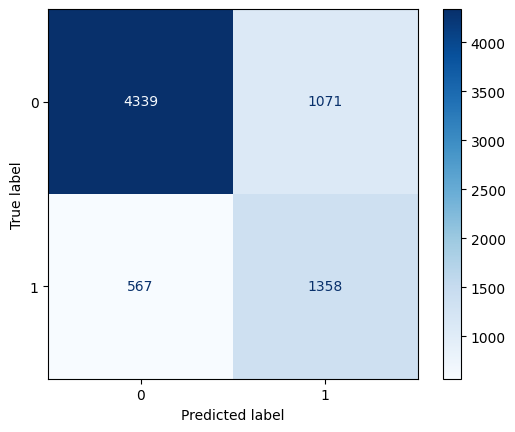

In [44]:
# Exibe a matriz de confusão para o LightGBM
print("Matriz de Confusão - LightGBM:")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lgbm, cmap='Blues');

In [45]:
# Salvar-modelo
# import os
# import cloudpickle

# with open(os.path.join(ROOT, 'models',"lightgbm-pipeline.pkl"), "wb") as f:
#     cloudpickle.dump(lightgbm_pipeline, f)

## Interpretabilidade

### Feature Importance

In [46]:
preprocessor = lightgbm_pipeline.named_steps['Preprocessing']
lgb_classifier = lightgbm_pipeline.named_steps['Classifier']
feature_importance = lgb_classifier.feature_importances_

X_train_val_ = preprocessing_pipeline_lgbm.fit_transform(X_train_val)
feature_names = X_train_val_.columns.tolist()

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

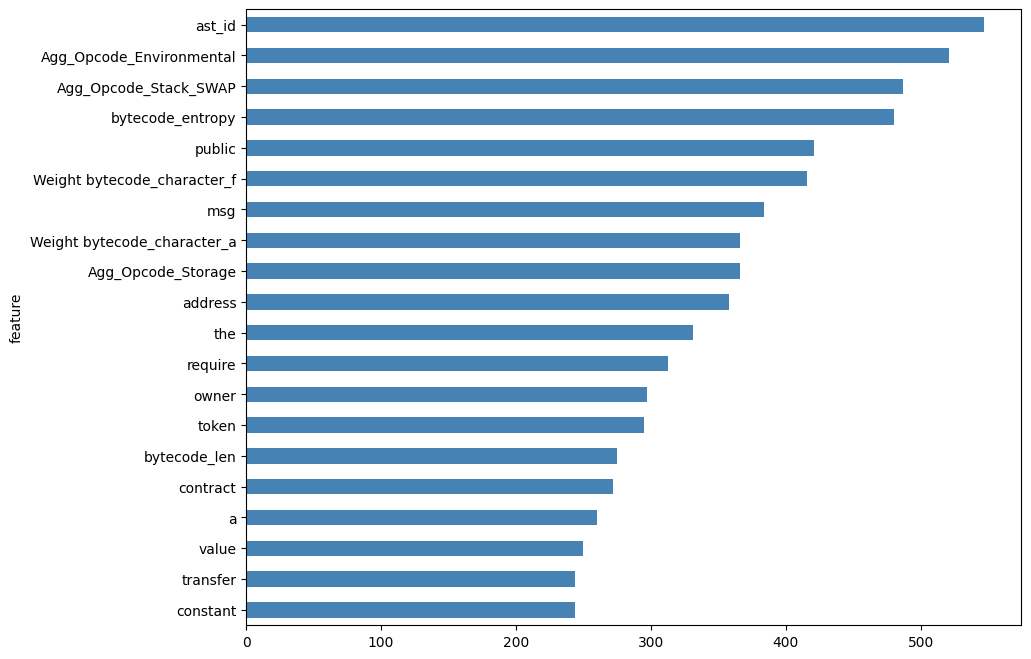

In [56]:
(feature_importance_df
 .head(20)
 .sort_values('importance', ascending=True)
 .tail(20)
 .set_index('feature')
 .plot(
        kind='barh',
        figsize=(10, 8),
        color='steelblue',
        legend=False
    )
);


# Gráfico de Importância de Atributos LightGBM
#
# Este gráfico/tabela exibe a importância global dos atributos conforme calculada
# pelo modelo LightGBM, baseada no 'ganho' (redução de impureza) que cada atributo
# proporciona nas divisões dos nós das árvores.
#
# - `ast_id` é o atributo mais importante, indicando que o modelo o utiliza de forma
#   frequente e eficaz para realizar separações nos dados que reduzem o erro de previsão.
#   Apesar de ser conceitualmente um 'id', sua alta relevância sugere que ele
#   age como um forte indicador categórico, agrupando características estruturais de
#   contratos que se correlacionam com a vulnerabilidade.
# - Outros atributos com alta importância incluem `Agg_Opcode_Environmental`, `bytecode_entropy`
#   e `Agg_Opcode_Stack_SWAP`, mostrando a dependência do modelo em padrões de opcode e
#   características de bytecode para a detecção de vulnerabilidades.
# - A ordem dos atributos reflete sua contribuição geral para as decisões de splitting
#   do modelo em todo o conjunto de dados.

### SHAP

In [48]:
X_test_ = preprocessing_pipeline_lgbm.transform(X_test)

In [49]:
# Cria O SHAP explainer
lightgbm_model = lightgbm_pipeline.named_steps['Classifier']
explainer = shap.TreeExplainer(lightgbm_model)

# Calcula os valores SHAP para o conjunto de teste
shap_values = explainer.shap_values(X_test_)

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


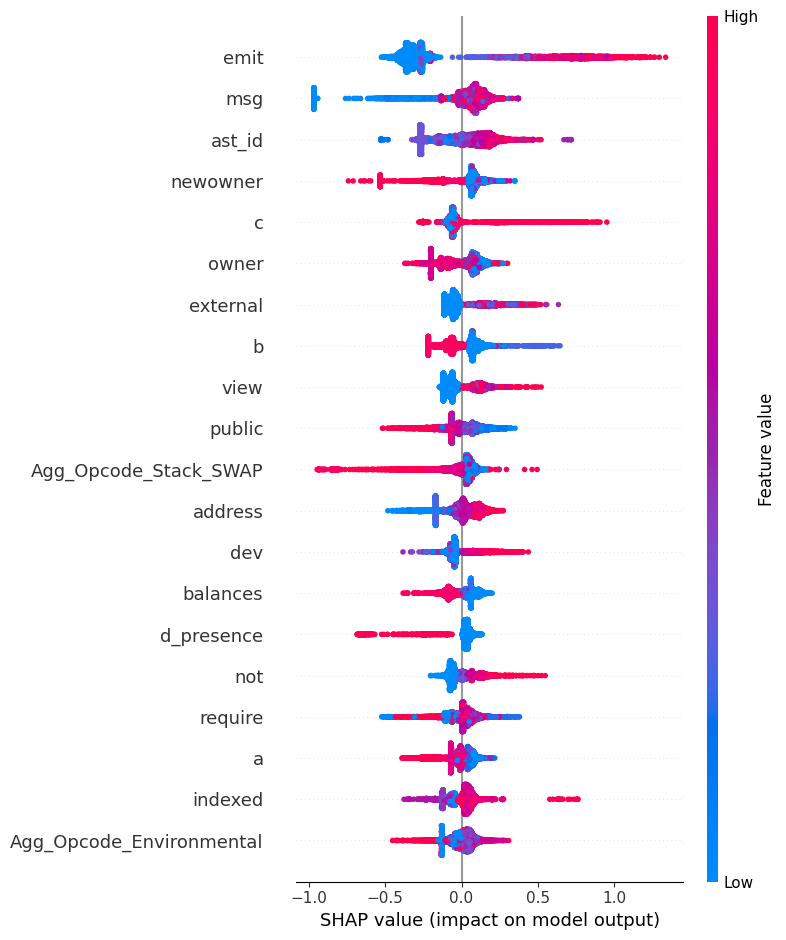

In [50]:
shap.summary_plot(shap_values, X_test_)

# Gráfico SHAP Summary Plot
#
# Este gráfico sumariza as contribuições SHAP de cada atributo para as previsões do modelo,
# ordenando-os por importância global (magnitude do impacto na saída do modelo).
#
# - `emit` é o atributo mais importante. Valores altos de `emit` (representados por pontos vermelhos)
#   impulsionam o modelo a prever uma maior probabilidade de vulnerabilidade, enquanto valores baixos
#   (pontos azuis) indicam menor probabilidade.
#
# - `msg` e `ast_id` também são atributos muito relevantes. Para `msg`, o gráfico mostra que
#   valores baixos (azuis) tendem a diminuir a previsão de vulnerabilidade, e valores altos (vermelhos)
#   tendem a aumentá-la, mas com uma distribuição mais dispersa para valores baixos.
#   Para `ast_id`, observa-se uma distribuição complexa, onde certos valores (vermelhos) aumentam
#   a previsão de vulnerabilidade, e outros (azuis) a diminuem.
#
# - Atributos como `newowner`, `c` e `owner` também demonstram forte influência nas previsões.
#   A cor do ponto (vermelho para valor alto do atributo, azul para valor baixo) e sua posição
#   no eixo X (impacto positivo ou negativo na predição) revelam como cada atributo influencia
#   a classificação de um contrato como vulnerável ou seguro.